In [10]:
import cv2  #opencv读取的格式是BGR
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
%matplotlib inline

def cv_show(name, img):
    cv2.imshow(name, img)  #image弹出的图片展示窗口名称，img为对象名
    cv2.waitKey(0)  #按任意键退出
    cv2.destroyAllWindows()

img_mount=cv2.imread('mount.jpg', cv2.IMREAD_GRAYSCALE)


Sobel算子
$$
\mathbf{G}_{x}=\left[\begin{array}{ccc}
-1 & 0 & +1 \\
-2 & 0 & +2 \\
-1 & 0 & +1
\end{array}\right] * \mathbf{A} \quad \text { and } \quad \mathbf{G}_{y}=\left[\begin{array}{ccc}
-1 & -2 & -1 \\
0 & 0 & 0 \\
+1 & +2 & +1
\end{array}\right] * \mathbf{A}
$$

In [11]:
sobelx=cv2.Sobel(img_mount,cv2.CV_64F,1,0,ksize=3)

```python
dst = cv2.Sobel(src, ddepth, dx, dy, ksize=3, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)
```

- ddepth：输出图像的深度，通常使用 cv2.CV_64F
- dy：y 方向上的导数阶数
- ksize：Sobel 核的大小，默认为 3。
- scale：缩放因子，默认为 1。
- delta：可选的 delta 值，默认为 0。
- borderType：边界填充类型，默认为 cv2.BORDER_DEFAULT。

(<Axes: title={'center': 'sobelx'}>,
 Text(0.5, 1.0, 'sobelx'))

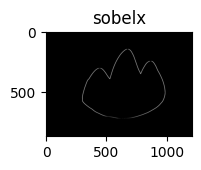

In [12]:
sobelx_abs = cv2.convertScaleAbs(sobelx)
plt.subplot(231),plt.imshow( sobelx_abs,"gray"),plt.title('sobelx')

总和
$$G=\sqrt{G_x^2+G_y^2}$$

```python
sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)
```
或者直接（官方推荐）
$$G=G_x*0.5+G_y*0.5$$
```python
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)
```


In [13]:
# 计算 x 方向的梯度
sobel_x = cv2.Sobel(img_mount, cv2.CV_64F, 1, 0, ksize=3)
sobel_x = cv2.convertScaleAbs(sobel_x)#取绝对值
# 计算 y 方向的梯度
sobel_y = cv2.Sobel(img_mount, cv2.CV_64F, 0, 1, ksize=3)
sobel_y = cv2.convertScaleAbs(sobel_y)
# 计算总梯度幅值
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)



(<Axes: title={'center': 'sobel_combined'}>,
 Text(0.5, 1.0, 'sobel_combined'))

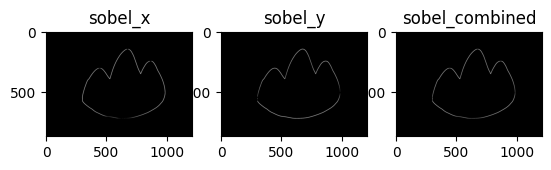

In [14]:
plt.subplot(131),plt.imshow(sobel_x ,"gray"),plt.title('sobel_x')
plt.subplot(132),plt.imshow(sobel_y ,"gray"),plt.title('sobel_y')
plt.subplot(133),plt.imshow(sobel_combined ,"gray"),plt.title('sobel_combined')

Scharr算子
$$
\mathbf{G}_{x}=\left[\begin{array}{lll}
-3 & 0 & 3 \\
-10 & 0 & 10 \\
-3 & 0 & 3
\end{array}\right] * \mathbf{A} \quad \text { and } \quad \mathbf{G}_{y}=\left[\begin{array}{ccc}
-3 & -10 & -3 \\
0 & 0 & 0 \\
-3 & -10 & -3
\end{array}\right] * \mathbf{A}
$$

特点：更加注重中间


In [15]:
scharr_x=cv2.Scharr(img_mount,cv2.CV_64F,1,0)
scharr_y=cv2.Scharr(img_mount,cv2.CV_64F,0,1)
scharr_x = cv2.convertScaleAbs(scharr_x)
scharr_y = cv2.convertScaleAbs(scharr_y)
scharr_xy=cv2.addWeighted(scharr_x, 0.5, scharr_y, 0.5, 0)

(<Axes: title={'center': 'scharr_xy'}>,
 Text(0.5, 1.0, 'scharr_xy'))

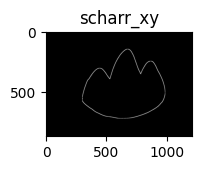

In [16]:
plt.subplot(131),plt.imshow(scharr_xy ,"gray"),plt.title('scharr_xy')

laplacian算子 拉普拉斯算子
$$
\left.\mathbf{G}=\left[
\begin{array}
{cccc}{0} & {1} & {0} \\
{1} & {-4} & {1} \\
{0} & {1} & {0}
\end{array}\right.\right]
$$
对中间更敏感

In [17]:
laplacian=cv2.Laplacian(img_mount,cv2.CV_64F,1)
laplacian = cv2.convertScaleAbs(laplacian)


(<Axes: title={'center': 'laplacian'}>,
 Text(0.5, 1.0, 'laplacian'))

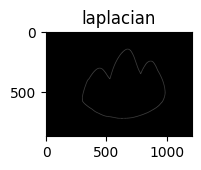

In [18]:
plt.subplot(131),plt.imshow(laplacian,"gray"),plt.title('laplacian')

三种方式对比


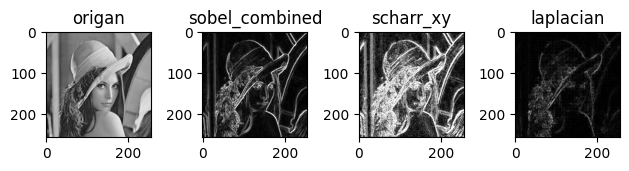

In [19]:
img_lena=cv2.imread('../../第六章 边缘检测/6-1 Canny边缘检测/lena.jpg', cv2.IMREAD_GRAYSCALE)


#sobel
# 计算 x 方向的梯度
sobel_x = cv2.Sobel(img_lena, cv2.CV_64F, 1, 0, ksize=3)
sobel_x = cv2.convertScaleAbs(sobel_x)  #取绝对值
# 计算 y 方向的梯度
sobel_y = cv2.Sobel(img_lena, cv2.CV_64F, 0, 1, ksize=3)
sobel_y = cv2.convertScaleAbs(sobel_y)
# 计算总梯度幅值
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

#scharr
scharr_x = cv2.Scharr(img_lena, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(img_lena, cv2.CV_64F, 0, 1)
scharr_x = cv2.convertScaleAbs(scharr_x)
scharr_y = cv2.convertScaleAbs(scharr_y)
scharr_xy = cv2.addWeighted(scharr_x, 0.5, scharr_y, 0.5, 0)

#laplacian
laplacian = cv2.Laplacian(img_lena, cv2.CV_64F, 1)
laplacian = cv2.convertScaleAbs(laplacian)

plt.subplot(141), plt.imshow(img_lena, "gray"), plt.title('origan')
plt.subplot(142), plt.imshow(sobel_combined, "gray"), plt.title('sobel_combined')
plt.subplot(143), plt.imshow(scharr_xy, "gray"), plt.title('scharr_xy')
plt.subplot(144), plt.imshow(laplacian, "gray"), plt.title('laplacian')
plt.tight_layout()



其实从结果看来，拉普拉斯算子不适合直接用，